In [1]:
subckt_555 = """\
* 555 Timer behavioral model -- 555.cir
*
* Version 2 using generic OpAmp model from the forum.
*    Now supports output voltage set by Vcc Pin.
*    This is mostly a timing model and may not be DC
*    accurate in all cases.
*
*           Ground
*           | Trigger
*           | | Output
*           | | | Reset
*           | | | | Control
*           | | | | | Threshold
*           | | | | | | Discharge
*           | | | | | | | Vcc
*           | | | | | | | |
.subckt 555 1 2 3 4 5 6 7 8 

R1  8  5 5000
R2  5 10 5000
R3 10  1 5000

X1  6 5 8 0 11  genopa1    ; the reset comparitor
X2 10 2 8 0 12  genopa1    ; the set comparitor


*        R  S    R  S
abridge [11 12] [22 21] adc_buff ; bridge from comparitors to set reset controls

a0 z1 pulldown1            ; pull-down for unused clock and data

*  data  clock set reset q   qbar
a1  z1    z1   21   25   23   24  flop1  ; the flip flop


abridge1 [24] [13] dac1    ; bridge qbar to discharge timing cap, turn on Q1
abridge2 [24] [26] dac1    ; bridge qbar  to pseudo tristate driver

Q1 7  13 1 N               ; the discharge transistor


* Here is the active low master reset function from pin 4.

abridge3 [4] [30] adc_buff ; bridge pin 4 to the digital domain

a2 30 31 inv1

a3 [22 31] 25 or1          ; Reset when the external resit is assered or the comparitor trips.
*
* Make the Q output of the flip-flop drive to Vcc when driven
*
R4 3 8 100                
Q2 3 26 0 N

* Models
.model adc_buff adc_bridge(in_low = 0.7 in_high = 3.0)  ; 0.7 V threshold per NE555 data sheet

.model flop1 d_dff(clk_delay = 13.0e-9 set_delay = 25.0e-9
+ reset_delay = 27.0e-9 ic = 0 rise_delay = 10.0e-9
+ fall_delay = 3e-9)

.model pulldown1 d_pulldown(load = 20.0e-12)

.model dac1 dac_bridge(out_low = 0.1 out_high = 1.0 out_undef = 2.2
+ input_load = 5.0e-12 t_rise = 50e-9
+ t_fall = 20e-9)

.model N NPN

.model inv1 d_inverter(rise_delay = 0.5e-9 fall_delay = 0.3e-9
+ input_load = 0.5e-12)

.model or1 d_or(rise_delay = 0.5e-9 fall_delay = 0.3e-9
+ input_load = 0.5e-12)

.ends

* generic OpAmp model
* gain, phase, offset, limits to power supply, input and output resistance

.subckt genopa1 in+ in- vcc vee out params: POLE=20 GAIN=20k VOFFSET=5m ROUT=10 RIN=10Meg

Rin   in+ in+ {RIN}
Voff  in+ inoff dc {VOFFSET}
G10   0 int inoff in- 100u
R1    int 0 {GAIN/100u}
C1    int 0 {1/(6.28*(GAIN/100u)*POLE)}
Eout  2 0 int 0 1
Rout  2 out {ROUT}
Elow  3 0 vee 0 1
Ehigh 8 0 vcc 0 1
Dlow  3   int Dlimit
Dhigh int 8   Dlimit 

.model Dlimit D N=0.01
.ends

.end
"""

with open('555.cir', 'w') as f:
    f.write(subckt_555)

print("555.cir written")

555.cir written


In [5]:
netlist = """\
555 Astable Mode
.include 555.cir

Vcc vcc 0 DC $VCC

Ra  vcc dis $RA
Rb  dis thr $RB
C1  thr 0   $C
Cc  con 0   10n

.ic v(thr)=0

*   gnd trig out rst  con  thr  dis  vcc
X1  0   thr  out vcc  con  thr  dis  vcc  555

.OPTIONS reltol=1e-3 abstol=1e-6 vntol=1e-4 itl4=100

.SAVE v(out) v(thr)

.TRAN $TSTEP $TEND
.END
"""

with open('555_astable_orig.cir', 'w') as f:
    f.write(netlist)

print("555_astable_orig.cir written")

555_astable_orig.cir written


In [4]:
import ngspice_calc as calc
import numpy as np
import matplotlib.pyplot as plt

Vcc = 5.0
Ra = 10e3
Rb = 10e3
C = 10e-6

f_theory = 1.44 / ((Ra + 2*Rb) * C)
T_theory = 1 / f_theory

duty = (Ra + Rb)/(Ra + 2*Rb)

n_cycles = 10
tend = n_cycles * T_theory

tstep = T_theory / 500

print(f'Theoretical frequency: {f_theory:.2f} Hz')
print(f'Theoretical period: {T_theory*1e3:.2f} ms')
print(f'Duty cycle: {duty*100:.1f} %')
print(f'Tend = {tend*1e3:.2f} ms')

Theoretical frequency: 4.80 Hz
Theoretical period: 208.33 ms
Duty cycle: 66.7 %
Tend = 2083.33 ms


In [5]:
l = [
    ('$VCC', f'{Vcc}'),
    ('$RA', f'{Ra:.2e}'),
    ('$RB', f'{Rb:.2e}'),
    ('$C', f'{C:.2e}'),
    ('$TSTEP', f'{tstep:.6e}'),
    ('$TEND', f'{tend:.6e}'),
]

calc.replace_strings_1('555_astable_orig.cir', '555_astable.cir', l)
calc.run_ngspice('555_astable.cir')


Note: No compatibility mode selected!


Circuit: 555 astable mode

binary raw file "555_astable.raw"
Reducing trtol to 1 for xspice 'A' devices
Doing analysis at TEMP = 27.000000 and TNOM = 27.000000

Using SPARSE 1.3 as Direct Linear Solver
No. of Data Columns : 3  

Initial Transient Solution
--------------------------

Node                                   Voltage
----                                   -------
vcc                                          5
dis                                        2.5
thr                                          0
con                                    3.33333
x1.10                                  1.66667
x1.x1.inoff                             -0.005
x1.x1.int                          -0.00626741
x1.x1.2                            -0.00626741
x1.11                              -0.00626741
x1.x1.3                                      0
x1.x1.8                                      5
x1.x2.inoff                            1.66167
x1.x2.int        

'555_astable.raw'

In [6]:
s = calc.slv('555_astable.cir')

for i in range(s.num_plots()):
    print(f"plot {i}: {s.plotname(i)} | type: {s.analysis_type(i)} | vars: {s.variables(i)}")

plot 0: Transient Analysis | type: tran | vars: ['time', 'v(out)', 'v(thr)']


In [7]:
t = s.get_array('time')
v_out = s.get_array('v(out)')
v_thr = s.get_array('v(thr)')

In [9]:
l_pos, l_neg = calc.cross_over_points(t, v_out, t[0], t[-1], 2.5)

if len(l_pos) >= 2:
    periods = np.diff(l_pos)
    f_actual = 1/np.mean(periods)
    print(f'Theoretical frequency: {f_theory:.2f} Hz')
    print(f"Measured frequency: {f_actual:.3f} Hz")
    print(f"Error: {abs(f_actual - f_theory)/f_theory * 100:.2f} %")
else:
    print("Not enough crossings found, simulate longer")

Theoretical frequency: 4.80 Hz
Measured frequency: 4.718 Hz
Error: 1.70 %


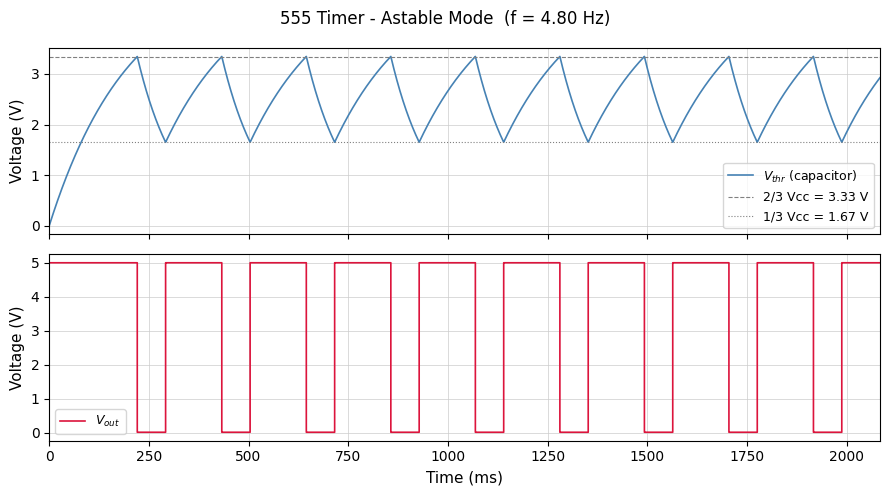

In [10]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
plt.subplots_adjust(hspace=0.08)

for ax in (ax1, ax2):
    ax.grid(color='#CCCCCC', linestyle='solid', linewidth=0.5)
    ax.set_xlim(t[0]*1e3, t[-1]*1e3)

ax1.plot(t*1e3, v_thr, color='steelblue', linewidth=1.2, label=r'$V_{thr}$ (capacitor)')
ax1.axhline(Vcc * 2/3, color='gray', linestyle='--', linewidth=0.8, label=f'2/3 Vcc = {Vcc*2/3:.2f} V')
ax1.axhline(Vcc * 1/3, color='gray', linestyle=':',  linewidth=0.8, label=f'1/3 Vcc = {Vcc*1/3:.2f} V')
ax1.set_ylabel('Voltage (V)', fontsize=11)
ax1.legend(fontsize=9)
ax1.tick_params(labelbottom=False)

ax2.plot(t*1e3, v_out, color='crimson', linewidth=1.2, label=r'$V_{out}$', drawstyle='steps-post')
ax2.set_ylabel('Voltage (V)', fontsize=11)
ax2.set_xlabel('Time (ms)', fontsize=11)
ax2.legend(fontsize=9)

plt.suptitle(f'555 Timer - Astable Mode  (f = {f_theory:.2f} Hz)', fontsize=12)
plt.tight_layout()
plt.show()